# Part 3: PCA, LDA, AE on many concatenated datasets. 
## Hope: Reproduce clean clusters from part 1 for the combined dataset

In [1]:
%load_ext autoreload
%autoreload 2
from utils import *

## PCA for concatenation of all 40 trees

### first, lets make sure our masks are working as expected:

combining data from all 40 files...


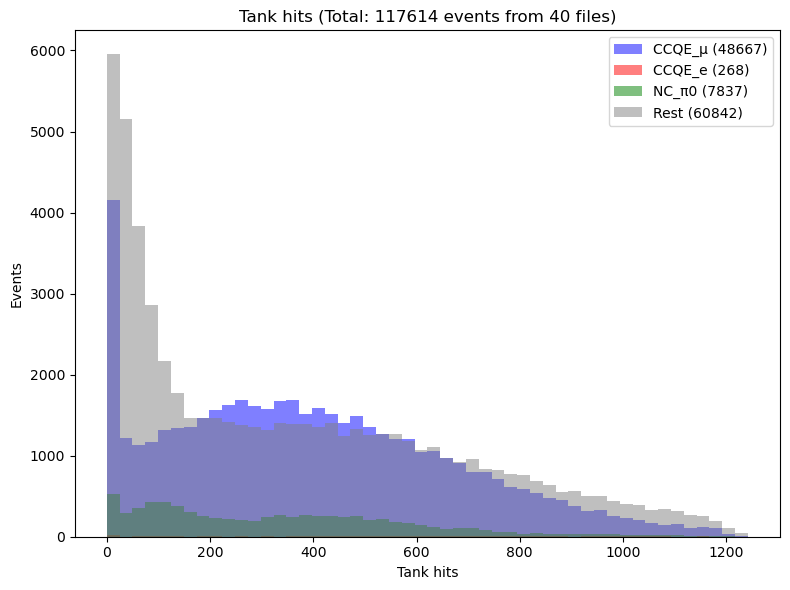

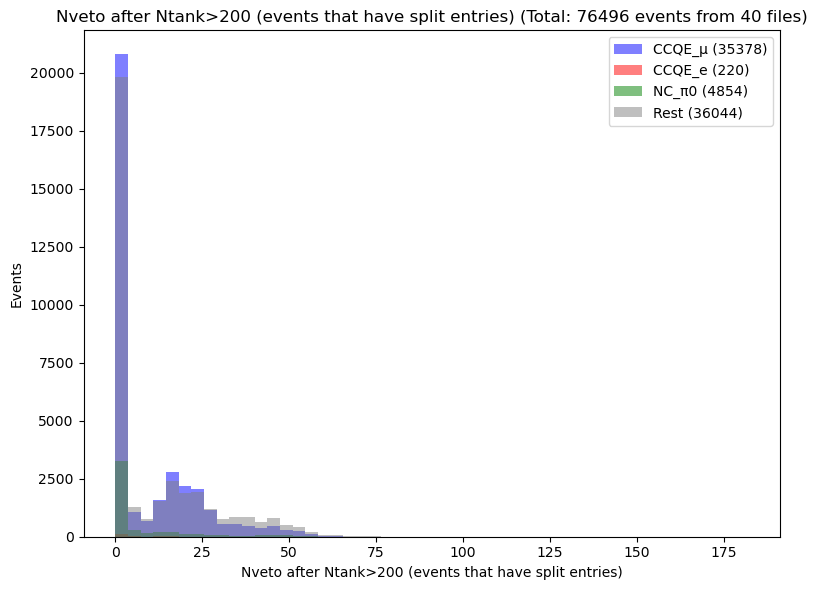

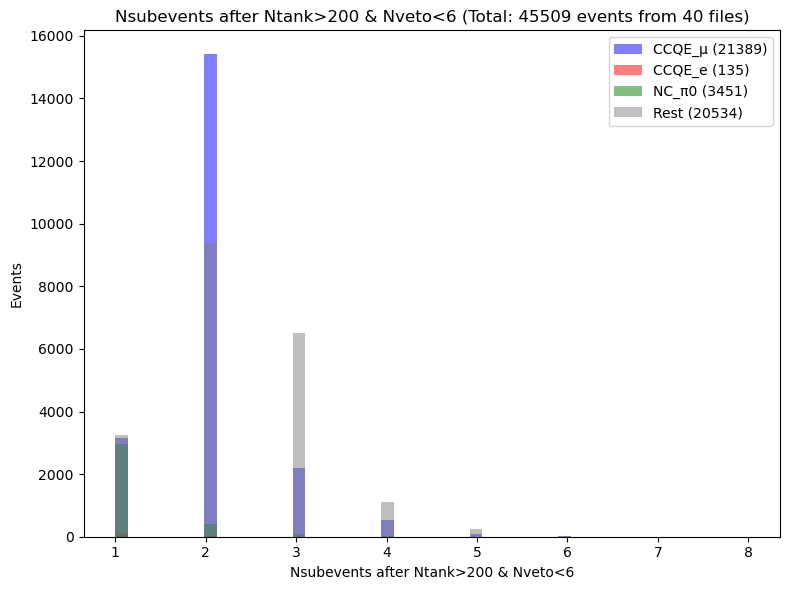

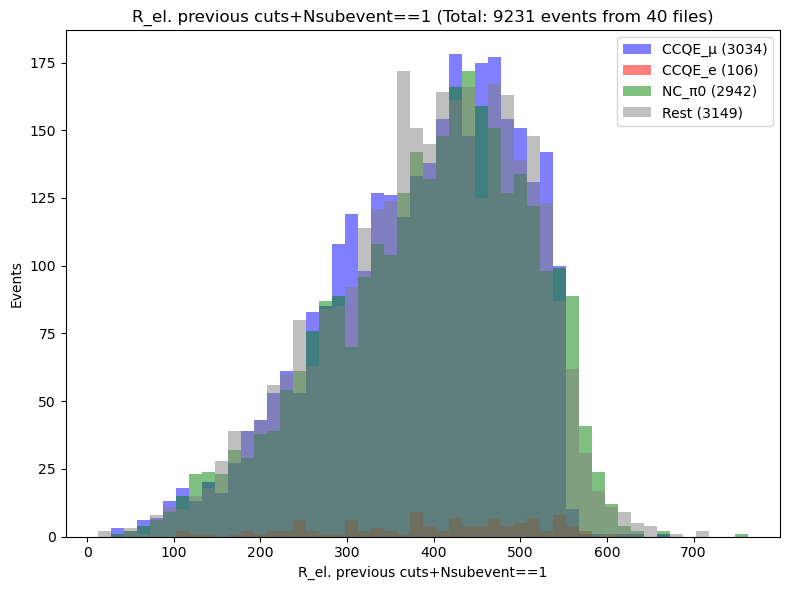

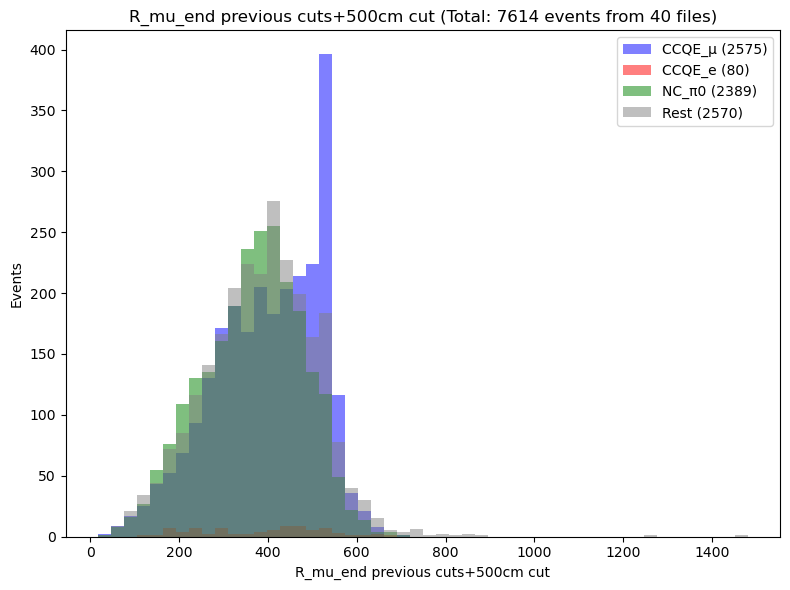

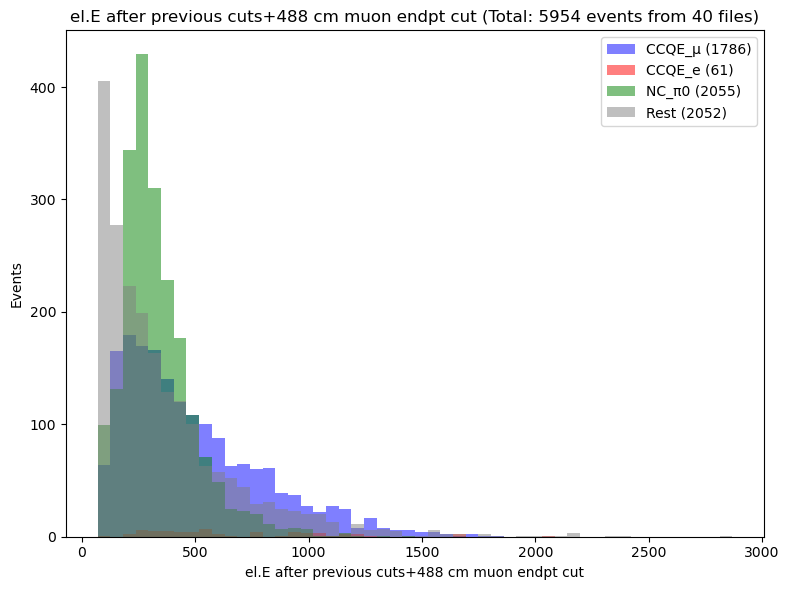

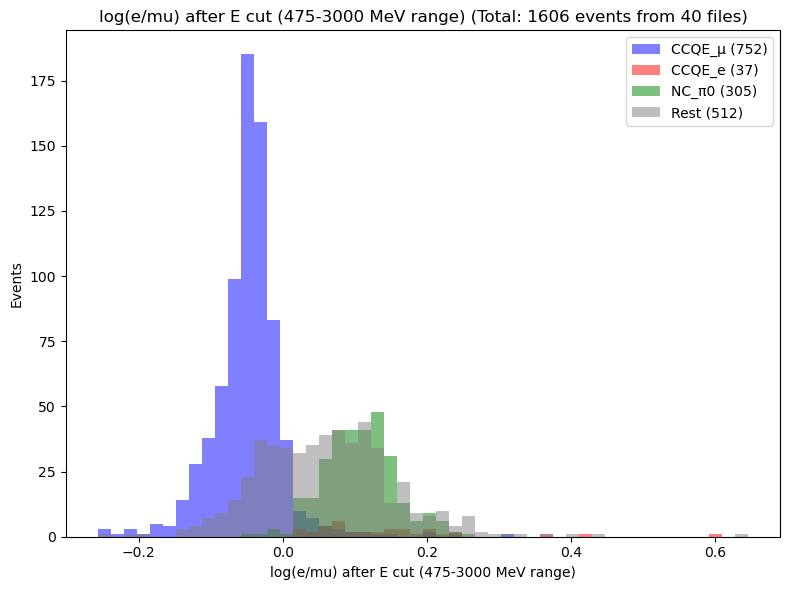

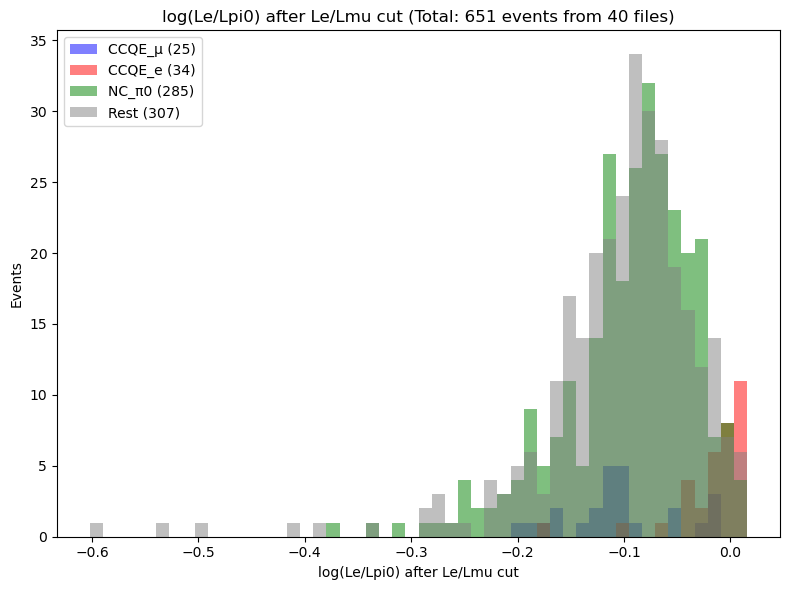

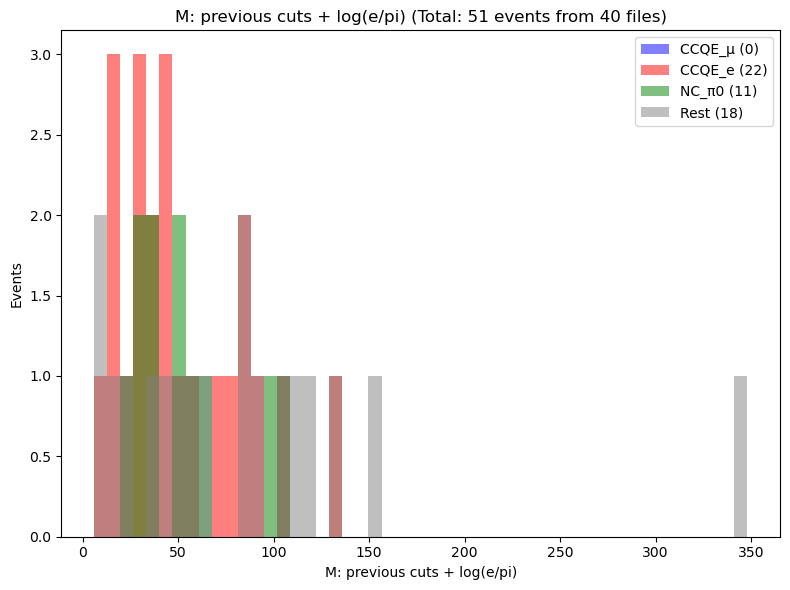


Final cut statistics (all 40 files combined):
Events passing all cuts: 51
  CCQE_μ: 0
  CCQE_e: 22
  NC_π0: 11
  Rest: 18


In [2]:
num_files = 40
#data loading
trees = {}
for i in range(1, num_files+1):
    idx = f"{i:04d}"  # zero-padded
    path = rf"C:\Users\Mathias\Desktop\NEUTRINO CODING\may07_2_cocktail_allhad_{idx}_updated.root"
    f = uproot.open(path)
    trees[idx] = f["MiniBooNE;1"]

all_keys = [f"{i:04d}" for i in range(1, num_files+1)] 

# concat
def concatenate_all_data(trees, keys_to_use):
    """Concatenate data from multiple trees for histogram plotting"""
    
    data_lists = {
        'nhits_all': [],
        'nveto_all': [],
        'subevent_all': [],
        # OT vars
        'ot_X': [],
        'ot_Y': [],
        'ot_Z': [],
        'ot_UX': [],
        'ot_UY': [],
        'ot_UZ': [],
        'dist_cer': [],
        'ot_E': [],
        'ot_F': [],
        # TT vars
        'twotrack_F': [],
        'twotrack_M': [],
        #inno, nuance
        'INNO': [],
        'nuance': []
    }
    
    for key in keys_to_use:
        tree = trees[key]
        
        data_lists['nhits_all'].append(tree["TSplitEventChunk/TSplitEventChunk.data_.THits"].array())
        data_lists['nveto_all'].append(tree["TSplitEventChunk/TSplitEventChunk.data_.VHits"].array())
        data_lists['subevent_all'].append(tree["TSplitEventChunk/TSplitEventChunk.data_.Subevent"].array())
        
        data_lists['ot_X'].append(tree["TOneTrackChunk/TOneTrackChunk.data_.X"].array())
        data_lists['ot_Y'].append(tree["TOneTrackChunk/TOneTrackChunk.data_.Y"].array())
        data_lists['ot_Z'].append(tree["TOneTrackChunk/TOneTrackChunk.data_.Z"].array())
        data_lists['ot_UX'].append(tree["TOneTrackChunk/TOneTrackChunk.data_.UX"].array())
        data_lists['ot_UY'].append(tree["TOneTrackChunk/TOneTrackChunk.data_.UY"].array())
        data_lists['ot_UZ'].append(tree["TOneTrackChunk/TOneTrackChunk.data_.UZ"].array())
        data_lists['dist_cer'].append(tree["TOneTrackChunk/TOneTrackChunk.data_.distToMeanCer"].array())
        data_lists['ot_E'].append(tree["TOneTrackChunk/TOneTrackChunk.data_.E"].array())
        data_lists['ot_F'].append(tree["TOneTrackChunk/TOneTrackChunk.data_.F"].array())
        
        data_lists['twotrack_F'].append(tree["TTwoTrackChunk/TTwoTrackChunk.data_.F"].array())
        data_lists['twotrack_M'].append(tree["TTwoTrackChunk/TTwoTrackChunk.data_.M"].array())
        
        data_lists['INNO'].append(tree["TMonteCarloEVNTChunk/TMonteCarloEVNTChunk.data_.INNO"].array())
        data_lists['nuance'].append(tree["TReweightToCVChunk/TReweightToCVChunk.data_.nuanceChannel"].array())
    
    # concat
    concatenated_data = {}
    for var_name, arrays in data_lists.items():
        concatenated_data[var_name] = ak.concatenate(arrays)
    
    return concatenated_data

print("combining data from all 40 files...")
data = concatenate_all_data(trees, all_keys)

#easier access to the vars
nhits_all = data['nhits_all']
nveto_all = data['nveto_all']
subevent_all = data['subevent_all']
ot_X = data['ot_X']
ot_Y = data['ot_Y']
ot_Z = data['ot_Z']
ot_UX = data['ot_UX']
ot_UY = data['ot_UY']
ot_UZ = data['ot_UZ']
dist_cer = data['dist_cer']
ot_E = data['ot_E']
ot_F = data['ot_F']
twotrack_F = data['twotrack_F']
twotrack_M = data['twotrack_M']
INNO = data['INNO']
nuance = data['nuance']

INNO_first = ak.firsts(INNO)
nuance_first = ak.firsts(nuance)

CCQE_mu_mask = ((INNO_first == 1) | (INNO_first == 2)) & (nuance_first == 1)
CCQE_e_mask = ((INNO_first == 3) | (INNO_first == 4)) & (nuance_first == 1)
NC_pi0_mask = (nuance_first == 6) | (nuance_first == 8) | (nuance_first == 96)
rest_mask = ~(CCQE_mu_mask | CCQE_e_mask | NC_pi0_mask)


def plot_with_categories_combined(values, mask, nbins, title, figsize=(8, 6)):
    
    values_masked = values[mask]
    
    #get categories for masked events
    CCQE_mu_masked = CCQE_mu_mask[mask]
    CCQE_e_masked = CCQE_e_mask[mask]
    NC_pi0_masked = NC_pi0_mask[mask]
    rest_masked = rest_mask[mask]
    
    fig, ax = plt.subplots(figsize=figsize)
    
    colors = {
        'CCQE_μ': 'blue',
        'CCQE_e': 'red',
        'NC_π0': 'green',
        'Rest': 'gray'
    }
    
    range_vals = (np.min(values_masked), np.max(values_masked))
    
    ax.hist(values_masked[CCQE_mu_masked], bins=nbins, range=range_vals, 
            alpha=0.5, label=f'CCQE_μ ({sum(CCQE_mu_masked)})', color=colors['CCQE_μ'])
    ax.hist(values_masked[CCQE_e_masked], bins=nbins, range=range_vals, 
            alpha=0.5, label=f'CCQE_e ({sum(CCQE_e_masked)})', color=colors['CCQE_e'])
    ax.hist(values_masked[NC_pi0_masked], bins=nbins, range=range_vals, 
            alpha=0.5, label=f'NC_π0 ({sum(NC_pi0_masked)})', color=colors['NC_π0'])
    ax.hist(values_masked[rest_masked], bins=nbins, range=range_vals, 
            alpha=0.5, label=f'Rest ({sum(rest_masked)})', color=colors['Rest'])
    
    ax.set_xlabel(title)
    ax.set_ylabel('Events')
    ax.set_title(f'{title} (Total: {len(values_masked)} events from 40 files)')
    ax.legend()
    
    plt.tight_layout()
    plt.show()

#now lets implement the cuts on the data

# cut 1
mask0 = empty_mask(nhits_all)
nhits_first = ak.fill_none(ak.firsts(nhits_all), -99999)
plot_with_categories_combined(nhits_first, mask0, 50, "Tank hits")

#cut 2
mask1 = mask0 & (nhits_first > 200)
nveto_first = ak.fill_none(ak.firsts(nveto_all), -99999)
plot_with_categories_combined(nveto_first, mask1, 50, "Nveto after Ntank>200 (events that have split entries)")

#cut 3
mask2 = mask1 & (nveto_first < 6) & empty_mask(subevent_all)
nsubevents = ak.num(subevent_all)
plot_with_categories_combined(nsubevents, mask2, 50, "Nsubevents after Ntank>200 & Nveto<6")

#cCut 4
mask3 = mask2 & (nsubevents == 1) & empty_mask(ot_X)
ot_X_first = ak.fill_none(ak.firsts(ot_X), -99999)
ot_Y_first = ak.fill_none(ak.firsts(ot_Y), -99999)
ot_Z_first = ak.fill_none(ak.firsts(ot_Z), -99999)
R_el = norm_calculator(ot_X_first, ot_Y_first, ot_Z_first)
plot_with_categories_combined(R_el, mask3, 50, "R_el. previous cuts+Nsubevent==1")

# cut 5
mask4 = mask3 & (R_el < 500) & empty_mask_second(dist_cer) & empty_mask_second(ot_X) & empty_mask_second(ot_UX)
endpoint_R_mu = calc_mu_endpt(ot_X, ot_Y, ot_Z, ot_UX, ot_UY, ot_UZ, dist_cer)
plot_with_categories_combined(endpoint_R_mu, mask4, 50, "R_mu_end previous cuts+500cm cut")

# cut 6
mask5 = mask4 & (endpoint_R_mu < 488) & empty_mask(ot_E)
E_el = ak.fill_none(ak.firsts(ot_E), -99999)
plot_with_categories_combined(E_el, mask5, 50, 'el.E after previous cuts+488 cm muon endpt cut')

# cut 7
mask6 = mask5 & (E_el > 475) & (E_el < 3000) & empty_mask_second(ot_F)
F_el = ak.fill_none(ak.firsts(ot_F), -99999)
F_mu = ak.fill_none(ak.pad_none(ot_F, 2)[:, 1], -99999)
log_Le_Lmu = F_mu - F_el
plot_with_categories_combined(log_Le_Lmu, mask6, 50, 'log(e/mu) after E cut (475-3000 MeV range)')

threshold_e_mu = 0.01355 + 0.03467*E_el/1000 - 0.008259*E_el**2/10**6

# cut 8
mask7 = mask6 & (log_Le_Lmu > threshold_e_mu) & empty_mask_second(twotrack_F)
F_pi0 = ak.fill_none(ak.pad_none(twotrack_F, 2)[:, 1], -99999)
log_Le_Lpi0 = F_pi0 - F_el
plot_with_categories_combined(log_Le_Lpi0, mask7, 50, "log(Le/Lpi0) after Le/Lmu cut")

threshold_e_pi0 = 0.002471 + 0.004115*E_el/1000 - 0.02738*E_el**2/10**6

# cut 9
mask8 = mask7 & (log_Le_Lpi0 > threshold_e_pi0) & empty_mask(twotrack_M)
M = ak.fill_none(ak.firsts(twotrack_M), -99999)
plot_with_categories_combined(M, mask8, 50, "M: previous cuts + log(e/pi)")

#stats
print("\nFinal cut statistics (all 40 files combined):")
print(f"Events passing all cuts: {sum(mask8)}")
print(f"  CCQE_μ: {sum(CCQE_mu_mask[mask8])}")
print(f"  CCQE_e: {sum(CCQE_e_mask[mask8])}")
print(f"  NC_π0: {sum(NC_pi0_mask[mask8])}")
print(f"  Rest: {sum(rest_mask[mask8])}")

## NEW APPROACH - since the 4 categories (ccqe_E, ccqe_MU, NN_Pi0, others), 
## presumably due to heterogeneity of "others", 
## lets just mask "others", run the LDA, and then just plot "others" in latent space.
## this way "others" doesnt break the LDA
### I think this approach with a few more refinements can go a long way

In [3]:
# PCA/LDA data processing stuff

# splitting data into train/val
train_keys = ["0001", "0002", "0003", "0004", "0005", "0006", "0007", "0008", "0009", "0010",
              "0011", "0012", "0013", "0014", "0015", "0016", "0017", "0018", "0019", "0020",
              "0021", "0022", "0023", "0024", "0025", "0026", "0027", "0028", "0029", "0030"]
val_keys = ["0031", "0032", "0033", "0034", "0035", "0036", "0037", "0038", "0039", "0040"]

def concatenate_tree_data(trees, keys_to_use):
    """Concatenate data from multiple trees"""
    data_lists = {
        'thits': [],
        'vhits': [],
        'subevent': [],
        'ot_X': [],
        'ot_Y': [],
        'ot_Z': [],
        'ot_UX': [],
        'ot_UY': [],
        'ot_UZ': [],
        'dist_cer': [],
        'ot_E': [],
        'ot_F': [],
        'twotrack_F': [],
        'twotrack_M': [],
        'INNO': [],
        'nuance': []
    }
    
    for key in keys_to_use:
        tree = trees[key]
        data_lists['thits'].append(tree["TSplitEventChunk/TSplitEventChunk.data_.THits"].array())
        data_lists['vhits'].append(tree["TSplitEventChunk/TSplitEventChunk.data_.VHits"].array())
        data_lists['subevent'].append(tree["TSplitEventChunk/TSplitEventChunk.data_.Subevent"].array())
        data_lists['ot_X'].append(tree["TOneTrackChunk/TOneTrackChunk.data_.X"].array())
        data_lists['ot_Y'].append(tree["TOneTrackChunk/TOneTrackChunk.data_.Y"].array())
        data_lists['ot_Z'].append(tree["TOneTrackChunk/TOneTrackChunk.data_.Z"].array())
        data_lists['ot_UX'].append(tree["TOneTrackChunk/TOneTrackChunk.data_.UX"].array())
        data_lists['ot_UY'].append(tree["TOneTrackChunk/TOneTrackChunk.data_.UY"].array())
        data_lists['ot_UZ'].append(tree["TOneTrackChunk/TOneTrackChunk.data_.UZ"].array())
        data_lists['dist_cer'].append(tree["TOneTrackChunk/TOneTrackChunk.data_.distToMeanCer"].array())
        data_lists['ot_E'].append(tree["TOneTrackChunk/TOneTrackChunk.data_.E"].array())
        data_lists['ot_F'].append(tree["TOneTrackChunk/TOneTrackChunk.data_.F"].array())
        data_lists['twotrack_F'].append(tree["TTwoTrackChunk/TTwoTrackChunk.data_.F"].array())
        data_lists['twotrack_M'].append(tree["TTwoTrackChunk/TTwoTrackChunk.data_.M"].array())
        data_lists['INNO'].append(tree["TMonteCarloEVNTChunk/TMonteCarloEVNTChunk.data_.INNO"].array())
        data_lists['nuance'].append(tree["TReweightToCVChunk/TReweightToCVChunk.data_.nuanceChannel"].array())
    
    concatenated_data = {}
    for var_name, arrays in data_lists.items():
        concatenated_data[var_name] = ak.concatenate(arrays)
    return concatenated_data

train_data = concatenate_tree_data(trees, train_keys)
val_data = concatenate_tree_data(trees, val_keys)

def process_combined_data(data):
    thits_first = ak.fill_none(ak.firsts(data['thits']), -99999)
    vhits_first = ak.fill_none(ak.firsts(data['vhits']), -99999)
    nsubevents = ak.num(data['subevent'])
    
    ot_X_first = ak.fill_none(ak.firsts(data['ot_X']), -99999)
    ot_Y_first = ak.fill_none(ak.firsts(data['ot_Y']), -99999)
    ot_Z_first = ak.fill_none(ak.firsts(data['ot_Z']), -99999)
    ot_UZ_first = ak.fill_none(ak.firsts(data['ot_UZ']), -99999)
    
    R_el = norm_calculator(ot_X_first, ot_Y_first, ot_Z_first)
    endpoint_R_mu = calc_mu_endpt(data['ot_X'], data['ot_Y'], data['ot_Z'], 
                                  data['ot_UX'], data['ot_UY'], data['ot_UZ'], 
                                  data['dist_cer'])
    
    E_el = ak.fill_none(ak.firsts(data['ot_E']), -99999)
    F_el = ak.fill_none(ak.firsts(data['ot_F']), -99999)
    F_mu = ak.fill_none(ak.pad_none(data['ot_F'], 2)[:, 1], -99999)
    log_Le_Lmu = F_mu - F_el
    
    F_pi0 = ak.fill_none(ak.pad_none(data['twotrack_F'], 2)[:, 1], -99999)
    log_Le_Lpi0 = F_pi0 - F_el
    
    M = ak.fill_none(ak.firsts(data['twotrack_M']), -99999)
    
    thresh_e_mu = 0.01355 + 0.03467*E_el/1000 - 0.008259*E_el**2/10**6
    thresh_e_pi0 = 0.002471 + 0.004115*E_el/1000 - 0.02738*E_el**2/10**6
    
    mask0 = (empty_mask(data['thits']) & 
             empty_mask(data['subevent']) & 
             empty_mask(data['ot_X']) & 
             empty_mask_second(data['dist_cer']) & 
             empty_mask_second(data['ot_X']) & 
             empty_mask_second(data['ot_UX']) &
             empty_mask(data['ot_E']) & 
             empty_mask_second(data['ot_F']) & 
             empty_mask_second(data['twotrack_F']) & 
             empty_mask(data['twotrack_M']))
    
    mask1 = mask0 & (thits_first > 200)
    mask2 = mask1 & (vhits_first < 6)
    mask3 = mask2 & (nsubevents == 1)
    mask4 = mask3 & (R_el < 500)
    mask5 = mask4 & (endpoint_R_mu < 488)
    mask6 = mask5 & (E_el > 475) & (E_el < 3000) 
    mask7 = mask6 & (log_Le_Lmu > thresh_e_mu)
    mask8 = mask7 & (log_Le_Lpi0 > thresh_e_pi0)
    
    INNO_first = ak.firsts(data['INNO'])
    nuance_first = ak.firsts(data['nuance'])
    
    CCQE_mu_mask = ((INNO_first == 1) | (INNO_first == 2)) & (nuance_first == 1)
    CCQE_e_mask = ((INNO_first == 3) | (INNO_first == 4)) & (nuance_first == 1)
    NC_pi0_mask = (nuance_first == 6) | (nuance_first == 8) | (nuance_first == 96)
    rest_mask = ~(CCQE_mu_mask | CCQE_e_mask | NC_pi0_mask)
    
    X = np.column_stack([
        thits_first, vhits_first, nsubevents, R_el, 
        endpoint_R_mu, E_el, log_Le_Lmu, log_Le_Lpi0, M, ot_UZ_first
    ])
    
    return X, mask7, CCQE_mu_mask, CCQE_e_mask, NC_pi0_mask, rest_mask

# processing the data
X_train, mask_train, CCQE_mu_train, CCQE_e_train, NC_pi0_train, rest_train = process_combined_data(train_data)
X_val, mask_val, CCQE_mu_val, CCQE_e_val, NC_pi0_val, rest_val = process_combined_data(val_data)

#masking n scaling
X_train_masked = X_train[mask_train]
X_val_masked = X_val[mask_val]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_masked)
X_val_scaled = scaler.transform(X_val_masked)

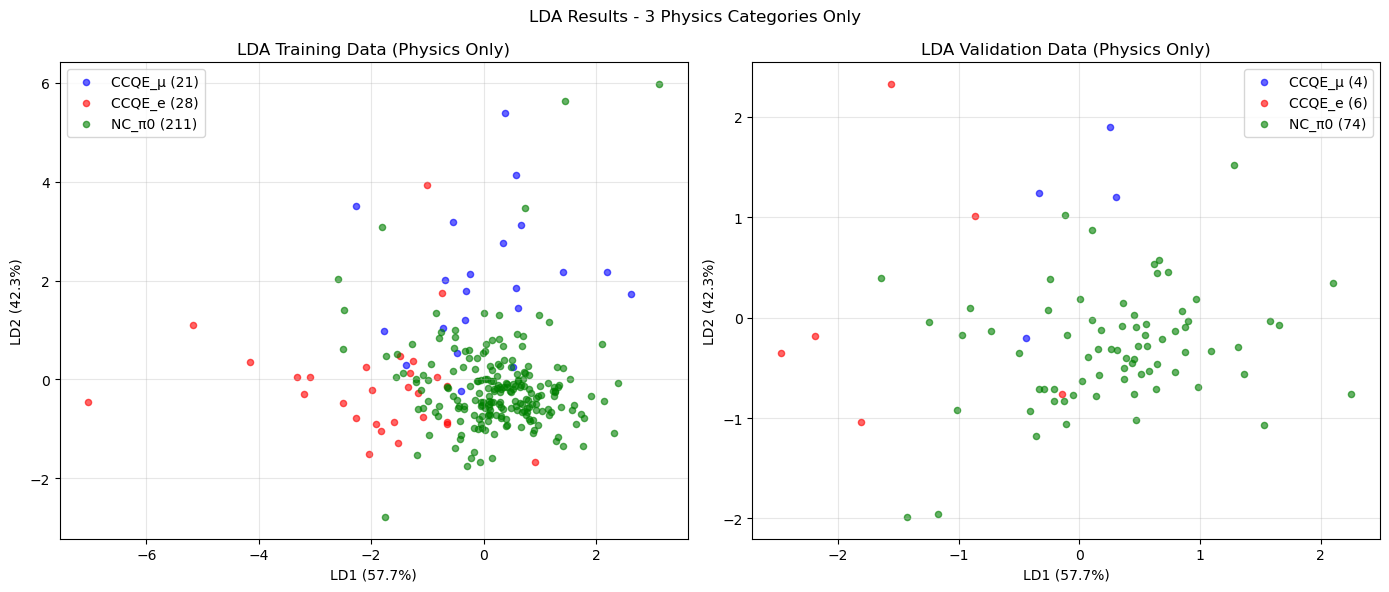

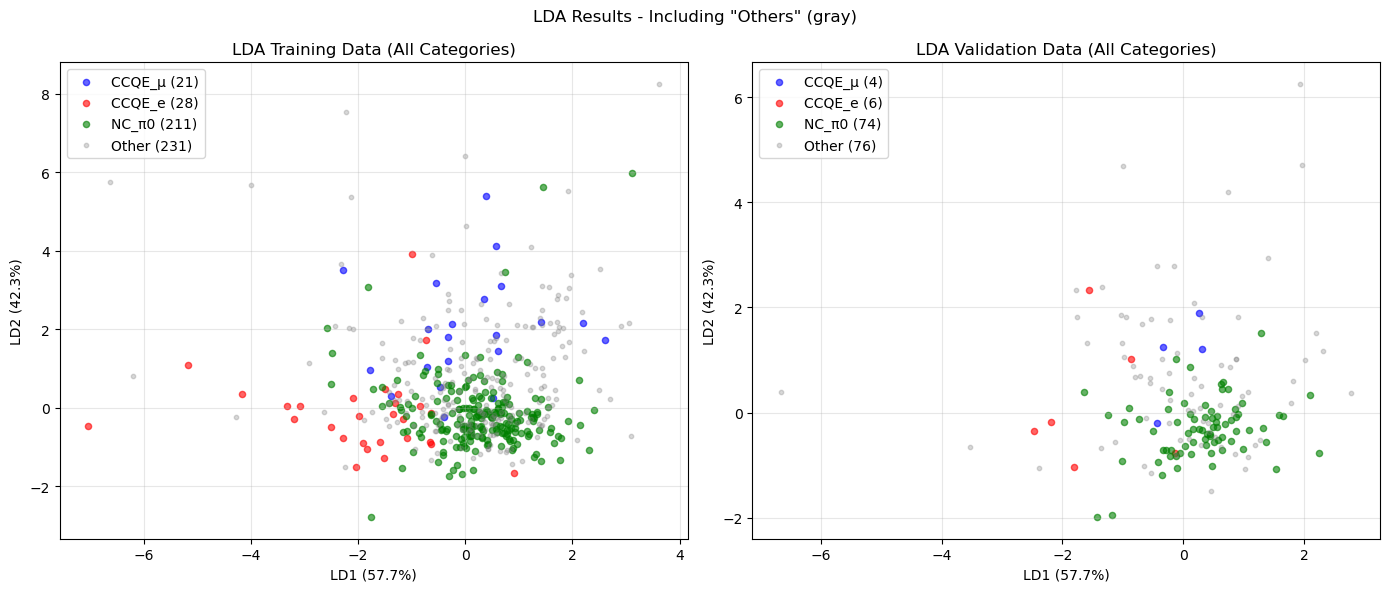

In [4]:
#labels for all 4 categories
def create_labels(CCQE_mu_mask, CCQE_e_mask, NC_pi0_mask, mask):
    """Create integer labels: 0=CCQE_μ, 1=CCQE_e, 2=NC_π0, 3=other"""
    labels = np.full(len(CCQE_mu_mask), 3)  # start with 3 (other)
    labels[CCQE_mu_mask] = 0
    labels[CCQE_e_mask] = 1  
    labels[NC_pi0_mask] = 2
    return labels[mask] 

#train and val labeling
y_train_all = create_labels(CCQE_mu_train, CCQE_e_train, NC_pi0_train, mask_train)
y_val_all = create_labels(CCQE_mu_val, CCQE_e_val, NC_pi0_val, mask_val)

# masks for NOT being "others"
physics_mask_train = y_train_all != 3
physics_mask_val = y_val_all != 3

#train LDA on ONLY the 3 physics categories
X_train_physics = X_train_scaled[physics_mask_train]
y_train_physics = y_train_all[physics_mask_train]

lda = LinearDiscriminantAnalysis(n_components=2)  
lda.fit(X_train_physics, y_train_physics)

# transform ALL data (including "others")
X_train_lda = lda.transform(X_train_scaled)
X_val_lda = lda.transform(X_val_scaled)

#FIRST plotting just the 3 physics categories (no "others")
fig1, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

colors = {0: 'blue', 1: 'red', 2: 'green', 3: 'gray'}
labels_dict = {0: 'CCQE_μ', 1: 'CCQE_e', 2: 'NC_π0', 3: 'Other'}

for label in [0, 1, 2]:  
    mask = (y_train_all == label)
    if sum(mask) > 0:
        ax1.scatter(X_train_lda[mask, 0], X_train_lda[mask, 1], 
                   c=colors[label], label=f'{labels_dict[label]} ({sum(mask)})',
                   alpha=0.6, s=20)

ax1.set_xlabel(f'LD1 ({lda.explained_variance_ratio_[0]:.1%})')
ax1.set_ylabel(f'LD2 ({lda.explained_variance_ratio_[1]:.1%})')
ax1.set_title(f'LDA Training Data (Physics Only)')
ax1.legend()
ax1.grid(True, alpha=0.3)

for label in [0, 1, 2]: 
    mask = (y_val_all == label)
    if sum(mask) > 0:
        ax2.scatter(X_val_lda[mask, 0], X_val_lda[mask, 1], 
                   c=colors[label], label=f'{labels_dict[label]} ({sum(mask)})',
                   alpha=0.6, s=20)

ax2.set_xlabel(f'LD1 ({lda.explained_variance_ratio_[0]:.1%})')
ax2.set_ylabel(f'LD2 ({lda.explained_variance_ratio_[1]:.1%})')
ax2.set_title(f'LDA Validation Data (Physics Only)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('LDA Results - 3 Physics Categories Only')
plt.tight_layout()
plt.show()

#NOW plot all 4 categories including "others"
fig2, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

for label in [0, 1, 2, 3]:
    mask = y_train_all == label
    if sum(mask) > 0:
        ax1.scatter(X_train_lda[mask, 0], X_train_lda[mask, 1], 
                   c=colors[label], label=f'{labels_dict[label]} ({sum(mask)})',
                   alpha=0.6 if label != 3 else 0.3, s=20 if label != 3 else 10)

ax1.set_xlabel(f'LD1 ({lda.explained_variance_ratio_[0]:.1%})')
ax1.set_ylabel(f'LD2 ({lda.explained_variance_ratio_[1]:.1%})')
ax1.set_title(f'LDA Training Data (All Categories)')
ax1.legend()
ax1.grid(True, alpha=0.3)

for label in [0, 1, 2, 3]:
    mask = y_val_all == label
    if sum(mask) > 0:
        ax2.scatter(X_val_lda[mask, 0], X_val_lda[mask, 1], 
                   c=colors[label], label=f'{labels_dict[label]} ({sum(mask)})',
                   alpha=0.6 if label != 3 else 0.3, s=20 if label != 3 else 10)

ax2.set_xlabel(f'LD1 ({lda.explained_variance_ratio_[0]:.1%})')
ax2.set_ylabel(f'LD2 ({lda.explained_variance_ratio_[1]:.1%})')
ax2.set_title(f'LDA Validation Data (All Categories)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('LDA Results - Including "Others" (gray)')
plt.tight_layout()
plt.show()

## i did the same analysis as above but with AEs, however results are not any better so i chose to not clog up this file even more